In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import pyiga

import scipy
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import csc_matrix, csr_matrix, coo_matrix
from scipy.sparse.linalg import aslinearoperator

np.set_printoptions(linewidth=100000)
np.set_printoptions(precision=5)

from pyiga import bspline, assemble, vform, geometry, vis, solvers, topology, bspline_cy


In [163]:
xi = np.linspace(0,1,1001)

In [164]:
deg=2
kv0 = bspline.make_knots(deg,0,1,5) 
kv1 = kv0.h_refine()
kv2 = kv1.h_refine()

P0 = bspline.prolongation(kv0,kv1).toarray()[6:10,0:4]
P1 = bspline.prolongation(kv1,kv2).toarray()[18:22,6:10]

In [165]:
P1

array([[0.  , 0.  , 0.  , 0.75],
       [0.  , 0.  , 0.  , 0.25],
       [0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  ]])

In [218]:
hbasis0 = [bspline.BSplineFunc(kv0, np.eye(1, kv0.numdofs, i).ravel()) for i in (0,1,2,3)]
hbasis1 = [bspline.BSplineFunc(kv1, np.eye(1, kv1.numdofs, i).ravel()) for i in (6,7,8,9)]
hbasis2 = [bspline.BSplineFunc(kv2, np.eye(1, kv2.numdofs, i).ravel()) for i in (18,19,20,21)]

thbasis0 = hbasis0.copy()
thbasis1 = hbasis1.copy()
thbasis2 = hbasis2.copy()

thbasis0[-1] = lambda xi: hbasis0[-1](xi) - 0.75*hbasis1[0](xi) -0.25*hbasis1[1](xi)
thbasis1[-1] = lambda xi: hbasis1[-1](xi) - 0.75*hbasis2[0](xi) -0.25*hbasis2[1](xi)

mesh0, m0 = kv0.mesh[0:4], kv0.m[0:4]
mesh1, m1 = kv1.mesh[6:10], kv1.m[6:10]
mesh2, m2 = kv2.mesh[18:22], kv2.m[18:22]

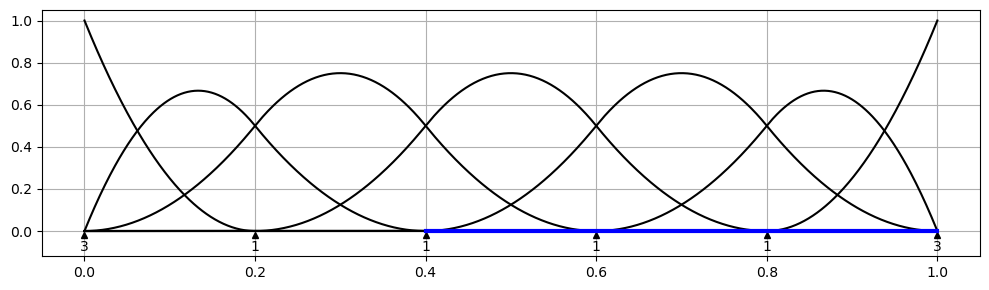

In [266]:
fig,ax = plt.subplots(figsize=(10,3))
kv0.plot(color='black',ax=ax);
ax.plot(np.array([0.4,1.0]),np.array([0.0,0.0]),color='blue',linewidth=3);
plt.savefig('/home/wolfman/Pictures/HB0.pdf',bbox_inches='tight');

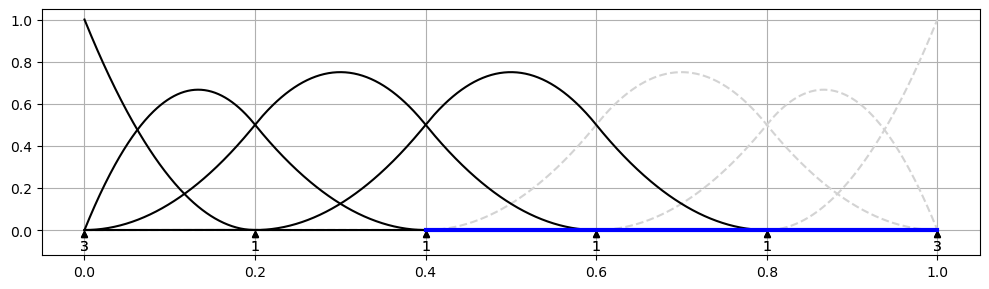

In [267]:
fig,ax = plt.subplots(figsize=(10,3))
kv0.plot(color='lightgray',ax=ax, idx=(4,5,6), linestyle='--');
kv0.plot(color='black',ax=ax, idx=(0,1,2,3));
ax.plot(np.array([0.4,1.0]),np.array([0.0,0.0]),color='blue',linewidth=3);
plt.savefig('/home/wolfman/Pictures/HB1.pdf',bbox_inches='tight');

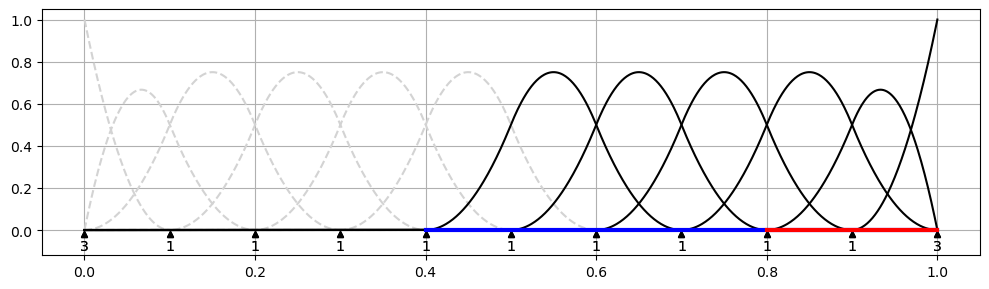

In [270]:
fig,ax = plt.subplots(figsize=(10,3))
kv1.plot(ax=ax, color='lightgray', idx=(0,1,2,3,4,5), linestyle='--');
kv1.plot(ax=ax, color='black', idx=(6,7,8,9,10,11));
ax.plot(np.array([0.4,1.0]),np.array([0.0,0.0]),color='blue',linewidth=3);
ax.plot(np.array([0.8,1.0]),np.array([0.0,0.0]),color='red',linewidth=3);
plt.savefig('/home/wolfman/Pictures/HB3.pdf',bbox_inches='tight');

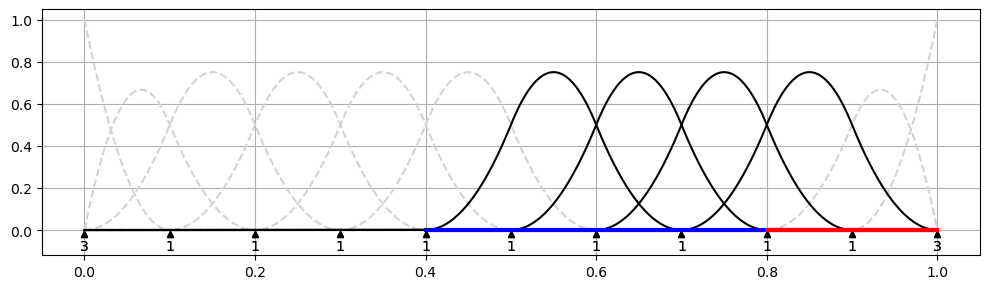

In [288]:
fig,ax = plt.subplots(figsize=(10,3))
kv1.plot(ax=ax, color='lightgray', idx=(0,1,2,3,4,5,10,11), linestyle='--');
kv1.plot(ax=ax, color='black', idx=(6,7,8,9));
ax.plot(np.array([0.4,1.0]),np.array([0.0,0.0]),color='blue',linewidth=3);
ax.plot(np.array([0.8,1.0]),np.array([0.0,0.0]),color='red',linewidth=3);
plt.savefig('/home/wolfman/Pictures/HB4.pdf',bbox_inches='tight');

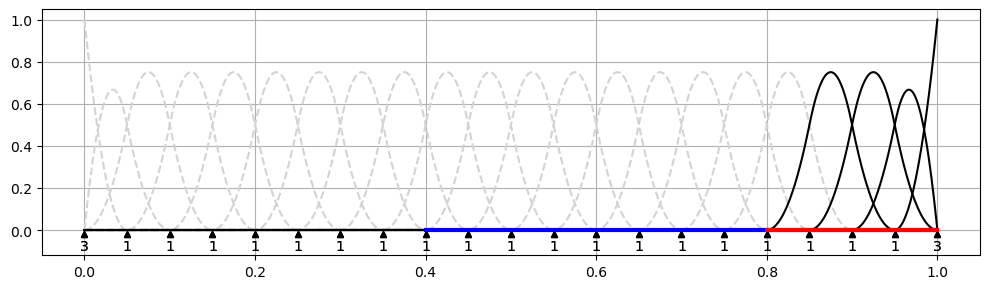

In [289]:
fig,ax = plt.subplots(figsize=(10,3))
kv2.plot(ax=ax, color='lightgray', idx=(0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17), linestyle='--');
kv2.plot(ax=ax, color='black', idx=(18,19,20,21));
ax.plot(np.array([0.4,1.0]),np.array([0.0,0.0]),color='blue', linewidth=3);
ax.plot(np.array([0.8,1.0]),np.array([0.0,0.0]),color='red', linewidth=3);
plt.savefig('/home/wolfman/Pictures/HB5.pdf',bbox_inches='tight');

In [279]:
mesh1

array([0.6, 0.7, 0.8, 0.9])

In [284]:
mesh2

array([0.9 , 0.95, 1.  ])

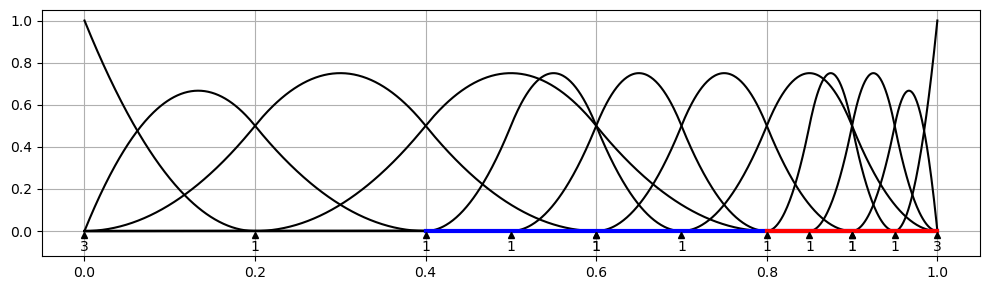

In [334]:
fig,ax = plt.subplots(figsize=(10,3))
kv0.plot(color='black',ax=ax, idx=(0,1,2,3), knots=False);
kv1.plot(ax=ax, color='black', idx=(6,7,8,9), knots=False);
kv2.plot(ax=ax, color='black', idx=(18,19,20,21), knots=False);
ax.plot(np.array([0.4,1.0]),np.array([0.0,0.0]),color='blue',linewidth=3);
ax.plot(np.array([0.8,1.0]),np.array([0.0,0.0]),color='red',linewidth=3);
for x, mi in zip(np.r_[mesh0,0.5,mesh1,0.85,mesh2], np.r_[m0,1,m1,1,m2]):
    plt.plot(x, -offset, marker="^", color="black", markersize=5)
    plt.annotate(str(mi),(x, -offset * 2.2),fontsize=10, ha="center",va="top")
plt.ylim(-0.12,1.05);
plt.savefig('/home/wolfman/Pictures/HB6.pdf',bbox_inches='tight');

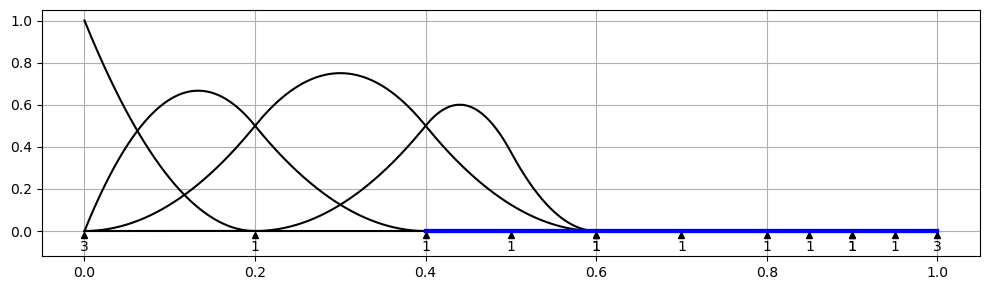

In [338]:
fig,ax = plt.subplots(figsize=(10,3))
for b in thbasis0:
    ax.plot(xi,b(xi),color='black')
ax.plot(np.array([0.4,1.0]),np.array([0.0,0.0]),color='blue',linewidth=3);
ax.grid(True)
ax.plot(np.array([0.4,1.0]),np.array([0.0,0.0]),color='blue',linewidth=3);
offset = 0.02
for x, mi in zip(np.r_[mesh0,0.5,mesh1,0.85,mesh2], np.r_[m0,1,m1,1,m2]):
    ax.plot(x, -offset, marker="^", color="black", markersize=5)
    ax.annotate(str(mi),(x, -offset * 2.2),fontsize=10, ha="center",va="top")
plt.ylim(-0.12,1.05);
plt.tight_layout()
plt.savefig('/home/wolfman/Pictures/THB0.pdf',bbox_inches='tight');

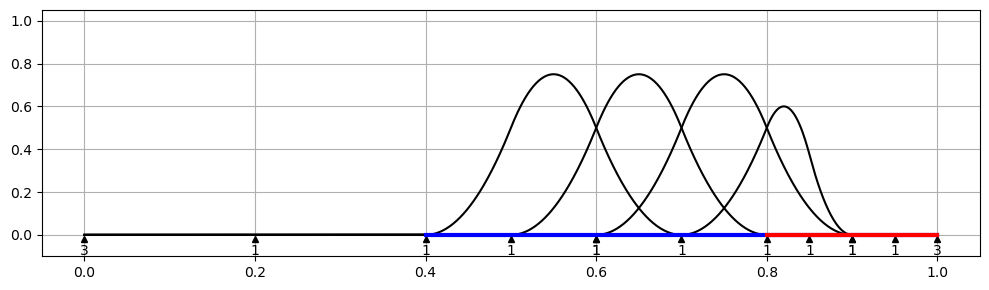

In [366]:
fig = plt.figure(figsize=(10,3))
for b in thbasis1:
    plt.plot(xi,b(xi),color='black')
plt.grid(True)
ax.plot(np.array([0.4,1.0]),np.array([0.0,0.0]),color='blue',linewidth=3);
offset = 0.02
for x, mi in zip(np.r_[mesh0,0.5,mesh1,0.85,mesh2], np.r_[m0,1,m1,1,m2]):
    plt.plot(x, -offset, marker="^", color="black", markersize=5)
    plt.annotate(str(mi),(x, -offset * 2.2),fontsize=10, ha="center",va="top")
plt.ylim(-0.1,1.05);
plt.plot(np.array([0.4,1.0]),np.array([0.0,0.0]),color='blue',linewidth=3);
plt.plot(np.array([0.8,1.0]),np.array([0.0,0.0]),color='red',linewidth=3);
plt.tight_layout()
plt.savefig('/home/wolfman/Pictures/THB1.pdf',bbox_inches='tight');

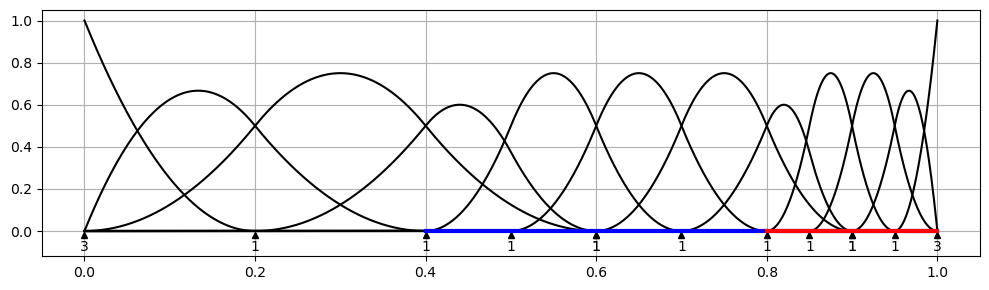

In [367]:
fig = plt.figure(figsize=(10,3))
for b in thbasis0:
    plt.plot(xi,b(xi),color='black')
for b in thbasis1:
    plt.plot(xi,b(xi),color='black')
for b in thbasis2:
    plt.plot(xi,b(xi),color='black')
plt.grid(True)
ax.plot(np.array([0.4,1.0]),np.array([0.0,0.0]),color='blue',linewidth=3);
offset = 0.02
for x, mi in zip(np.r_[mesh0,0.5,mesh1,0.85,mesh2], np.r_[m0,1,m1,1,m2]):
    plt.plot(x, -offset, marker="^", color="black", markersize=5)
    plt.annotate(str(mi),(x, -offset * 2.2),fontsize=10, ha="center",va="top")
plt.ylim(-0.12,1.05);
plt.plot(np.array([0.4,1.0]),np.array([0.0,0.0]),color='blue',linewidth=3);
plt.plot(np.array([0.8,1.0]),np.array([0.0,0.0]),color='red',linewidth=3);
plt.tight_layout()
plt.savefig('/home/wolfman/Pictures/THB2.pdf',bbox_inches='tight');

In [110]:
P = bspline.prolongation(kv0,kv1)

In [114]:
P.toarray()[:,0:4]

array([[1.  , 0.  , 0.  , 0.  ],
       [0.5 , 0.5 , 0.  , 0.  ],
       [0.  , 0.75, 0.25, 0.  ],
       [0.  , 0.25, 0.75, 0.  ],
       [0.  , 0.  , 0.75, 0.25],
       [0.  , 0.  , 0.25, 0.75],
       [0.  , 0.  , 0.  , 0.75],
       [0.  , 0.  , 0.  , 0.25],
       [0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  ]])

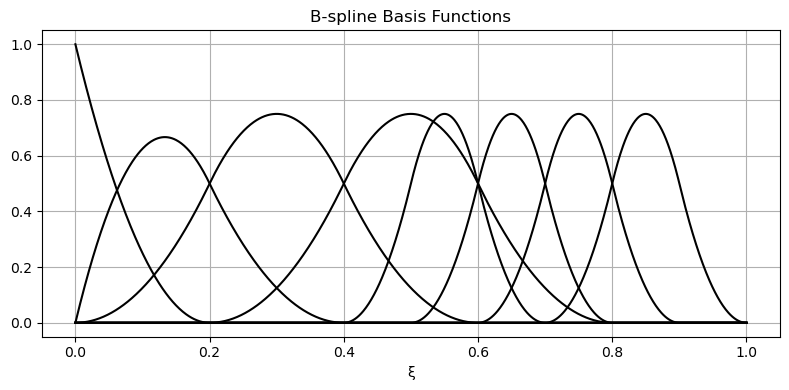

In [116]:
fig, ax = plt.subplots(figsize=(8, 4))
kv0.plot(idx = (0,1,2,3), ax=ax, knots=False, col='black')
kv1.plot(idx=(6,7,8,9), ax=ax, knots=False, col='black')
#kv2.plot(idx=(18,19,20,21),ax=ax, knots=False, col='black')

In [193]:
kv = bspline.KnotVector(np.array([0,0,0,0.2,0.4,0.5,0.6,0.7,0.8,0.85,0.9,0.95,1,1,1]),2)

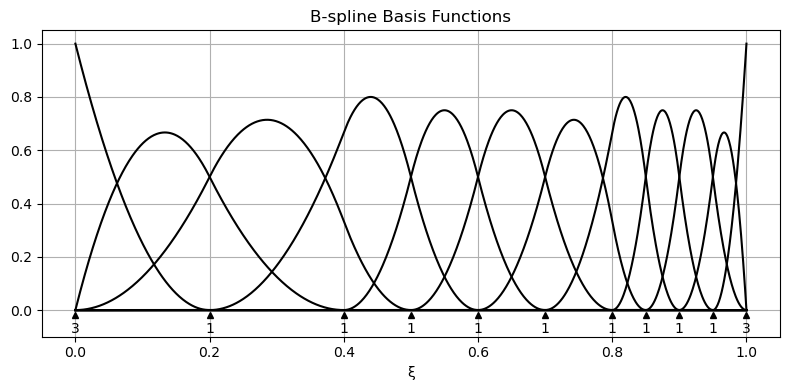

In [195]:
kv.plot(col='black')

In [2]:
deg=3
kv = bspline.KnotVector(np.array([0,0,0,0,0.25,0.25,0.5,0.5,0.5,0.75,0.75,1.0,1.0,1.0,1.0]),deg)
nodes = kv.greville()

1


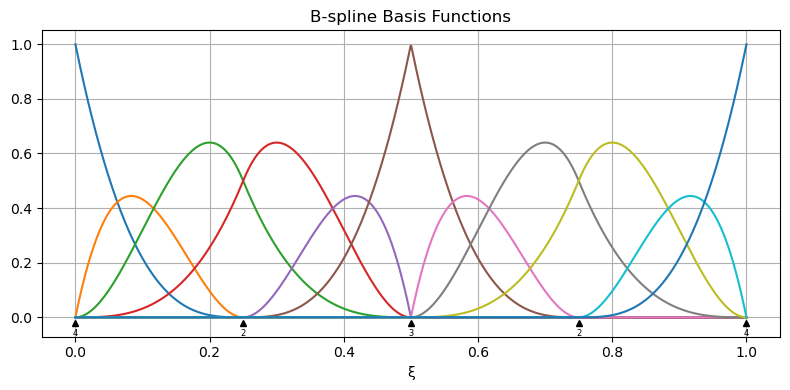

In [3]:
kv.plot(knots=1)
plt.savefig('Bsplinesexample.pdf',bbox_inches='tight');

In [345]:
from pyiga import hierarchical
hs = hierarchical.HSpace(2 * (bspline.make_knots(2, 0.0, 1.0, 5),),truncate=False, disparity=5,bdspecs=['left', 'right', 'top', 'bottom'])

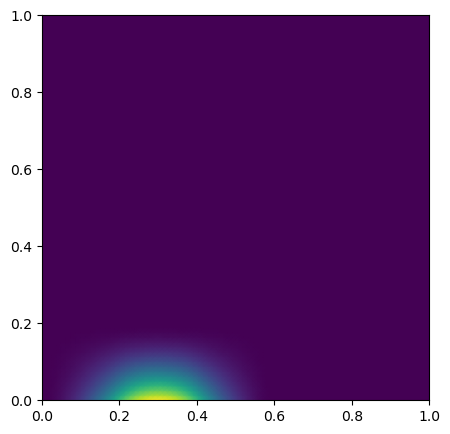

In [365]:
fig,ax = plt.subplots(figsize=(5,5))
for k in range(3):
    b = hierarchical.HSplineFunc(hs, np.eye(1,hs.numdofs,k).ravel())
    vis.plot_field(b,axis=ax)
plt.show()

In [295]:
kvs = (kv,kv)
n1 = n2 = kv.numdofs
n = n1*n2
k = 6
k1 = k // n1
k2 = k % n1
coeffs = np.eye(1,n,k).ravel()
coeffs1 = np.eye(1,n1,k1).ravel()
coeffs2 = np.eye(1,n2,k2).ravel()
phi  = bspline.BSplineFunc(kvs, coeffs)
phiy = bspline.BSplineFunc(kv,coeffs1)
phix = bspline.BSplineFunc(kv,coeffs2)

#im, _ = vis.plot_field(phi,res=300);
#plt.axis('scaled');
#plt.axis('off');
#plt.colorbar(im);
#plt.savefig('phi_hat.pdf',bbox_inches='tight');

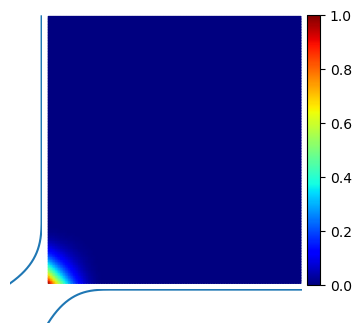

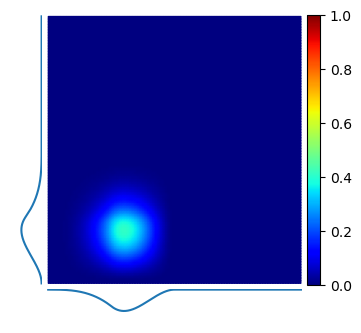

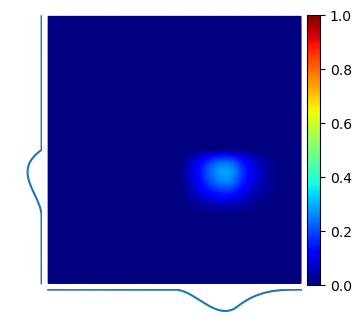

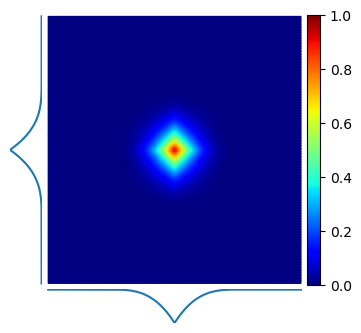

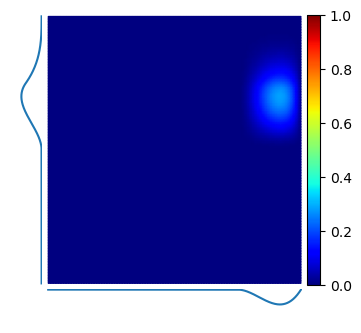

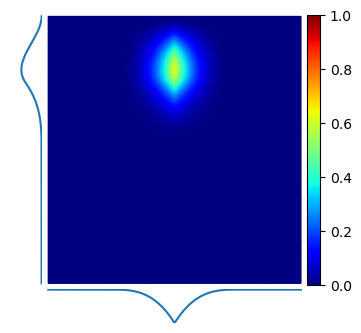

In [20]:
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
#fig = plt.figure(figsize=(6,6))
#gs = GridSpec(2,3, width_ratios=[1, 4, 0.2], height_ratios=[4,1], wspace=0.05, hspace=0.03)

xi = np.linspace(0,1,2**10+1)
kvs = (kv,kv)
n1 = n2 = kv.numdofs
n = n1*n2

for k in (0,25,51,60,86,93):
    fig = plt.figure(figsize=(4,4))
    gs = GridSpec(2,3, width_ratios=[0.5, 4, 0.2], height_ratios=[4,0.5], wspace=0.05, hspace=0.03)
    xi = np.linspace(0,1,2**10+1)

    k1 = k // n2
    k2 = k % n2
    coeffs = np.eye(1,n,k).ravel()
    coeffs1 = np.eye(1,n1,k1).ravel()
    coeffs2 = np.eye(1,n2,k2).ravel()
    phi  = bspline.BSplineFunc(kvs, coeffs)
    phiy = bspline.BSplineFunc(kv,coeffs1)
    phix = bspline.BSplineFunc(kv,coeffs2)

    ax_main = fig.add_subplot(gs[0, 1])
    im, _ = vis.plot_field(phi,res=100,vmin=0,vmax=1, cmap='jet');
    ax_main.set_xlim(0, 1)
    ax_main.set_ylim(0, 1)
    #ax_main.set_aspect('equal', adjustable='box')
    ax_main.axis('off')
    #plt.colorbar(im);
    
    ax_left = fig.add_subplot(gs[0, 0], sharey=ax_main)
    ax_left.plot(-phiy(xi),xi, color='C0')
    ax_left.set_ylim(0-0.005,1+0.005)
    ax_left.set_xlim(-1,0.01)
    #ax_left.invert_xaxis()
    #ax_bottom.set_ylim(0,1)
    #ax_left.axis('scaled');
    ax_left.axis('off');
    
    cax = fig.add_subplot(gs[0,2])
    norm = Normalize(vmin=0, vmax=1)  # desired colorbar range
    sm = ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])  # required for colorbar

    # Add colorbar using the independent ScalarMappable
    #plt.colorbar(sm)
    cb = fig.colorbar(sm, cax=cax)
    #add colorbar for the main contour here
    
    ax_bottom = fig.add_subplot(gs[1,1],sharex=ax_main)
    ax_bottom.plot(xi,-phix(xi), color='C0')
    ax_bottom.set_xlim(0-0.005, 1+0.005)
    ax_bottom.set_ylim(-1, 0.01)
    #ax_bottom.axis('scaled');
    ax_bottom.axis('off');

    #fig.suptitle(f"Basis function k={k}, indices ({k1}, {k2})")

    plt.show()
    fig.savefig(f"/home/wolfman/Pictures/TensorBspline_{k:03d}.pdf")
    plt.close(fig)

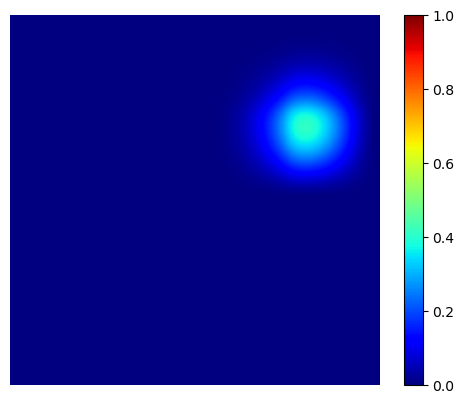

In [17]:
kvs=(kv,kv)
n = bspline.numdofs(kvs)
k = 85
coeffs = np.eye(1,n,k).ravel()
phi  = bspline.BSplineFunc(kvs, coeffs)

im,_ = vis.plot_field(phi, res=300, cmap='jet', vmin=0, vmax=1);
plt.axis('scaled');
plt.axis('off');
plt.colorbar(im);
plt.savefig('phi_hat.pdf',bbox_inches='tight');

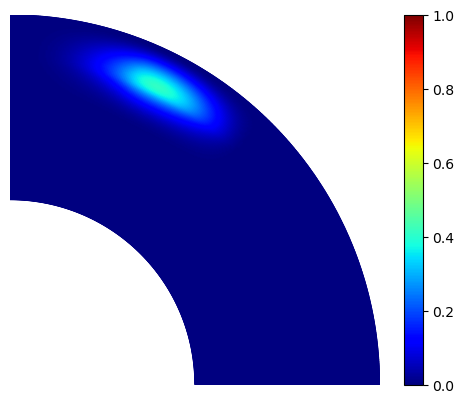

In [18]:
im,_ = vis.plot_field(phi, geo=geometry.quarter_annulus(), res=300, cmap='jet', vmin=0, vmax=1);
plt.axis('scaled');
plt.axis('off');
plt.colorbar(im);
plt.savefig('phi.pdf',bbox_inches='tight');

In [86]:
bspline_cy.pyx_checkSWcondition(kv.kv, kv.p, len(kv.kv), nodes, len(nodes))

True

In [87]:
C = bspline.collocation(kv,nodes)
print(C.shape[0]==np.linalg.matrix_rank(C.toarray()))

True


In [83]:
%timeit bspline.collocation(kv,nodes), C.shape[0]==np.linalg.matrix_rank(C.toarray())

17.8 ms ± 603 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [84]:
%timeit bspline_cy.pyx_checkSWcondition(kv.kv, kv.p, len(kv.kv), nodes, len(nodes))

369 ns ± 2.46 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [70]:
C.toarray()

array([[0.25 , 0.625, 0.125, 0.   , 0.   , 0.   ],
       [0.   , 0.5  , 0.5  , 0.   , 0.   , 0.   ],
       [0.   , 0.125, 0.75 , 0.125, 0.   , 0.   ]])

In [63]:
print(len(nodes),kv.numdofs,len(nodes)<=kv.numdofs)

3 5 True


In [64]:
for i in range(kv.numdofs):
    a,b = kv.support(i)
    count = sum((a + 1e-14 <= nodes) & (nodes  < b - 1e-14  ))
    print(count,kv.p+1,count<=kv.p+1)

1 2 True
3 2 False
1 2 True
0 2 True
0 2 True


In [65]:
C.shape[0]==np.linalg.matrix_rank(C.toarray())

True

In [10]:
C.toarray()

array([[1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.]])

In [25]:
C.shape[0]-np.linalg.matrix_rank(C.toarray())

2

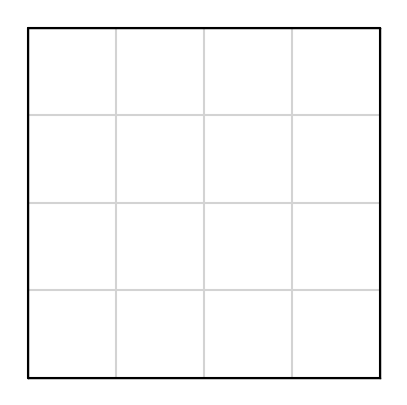

In [401]:
kv = bspline.make_knots(1,0,1,4)
M = topology.MultiPatch(patches=[((kv,kv),geometry.unit_square())])
M.plotmesh(knots=True)
plt.axis('off');
plt.savefig('/home/wolfman/Pictures/tensor_knot0.pdf',bbox_inches='tight');

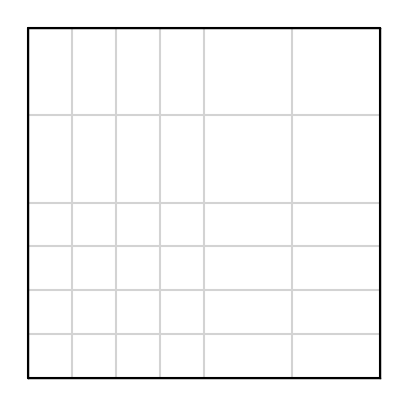

In [402]:
kv = bspline.KnotVector(np.array([0,0,0.125,0.25,0.375,0.5,0.75,1,1]),1)
M = topology.MultiPatch(patches=[((kv,kv),geometry.unit_square())])
M.plotmesh(knots=True)
plt.axis('off');
plt.savefig('/home/wolfman/Pictures/tensor_knot1.pdf',bbox_inches='tight');

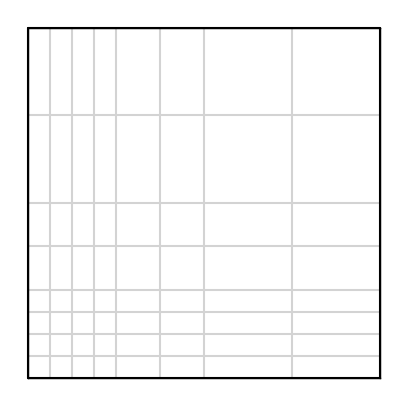

In [403]:
kv = bspline.KnotVector(np.array([0,0,0.0625,0.125,0.1875,0.25,0.375,0.5,0.75,1,1]),1)
M = topology.MultiPatch(patches=[((kv,kv),geometry.unit_square())])
M.plotmesh(knots=True)
plt.axis('off');
plt.savefig('/home/wolfman/Pictures/tensor_knot2.pdf',bbox_inches='tight');

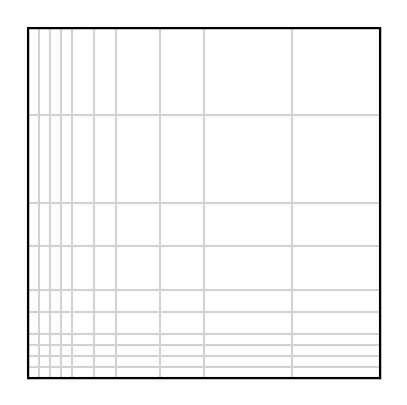

In [404]:
kv = bspline.KnotVector(np.array([0,0,0.03125,0.0625,0.09375,0.125,0.1875,0.25,0.375,0.5,0.75,1,1]),1)
M = topology.MultiPatch(patches=[((kv,kv),geometry.unit_square())])
M.plotmesh(knots=True)
plt.axis('off');
plt.savefig('/home/wolfman/Pictures/tensor_knot3.pdf',bbox_inches='tight');

In [393]:
0.0625/2+0.125/2

0.09375

In [412]:
def cart2pol(x, y):
    r = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    return(r, phi%(2*np.pi))
def u(x,y):
    r, phi = cart2pol(x,y)
    return r**(2/3)*np.sin(2*phi/3)

In [424]:
geos = (geometry.Quad(np.array([[-1,-1],[0,-1],[-1,1],[0,0]]).T),geometry.Quad(np.array([[-1,1],[0,0],[1,1],[1,0]]).T))

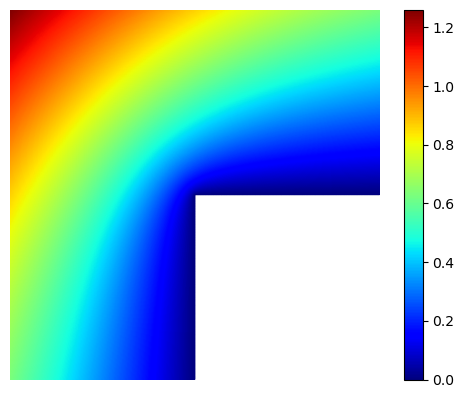

In [441]:
for geo in geos:
    im,ax = vis.plot_field(u, geo=geo, physical=True, cmap='jet', res=300);
plt.axis('scaled');
plt.axis('off');
plt.colorbar(im);
plt.savefig('/home/wolfman/Pictures/exact.pdf',bbox_inches='tight');

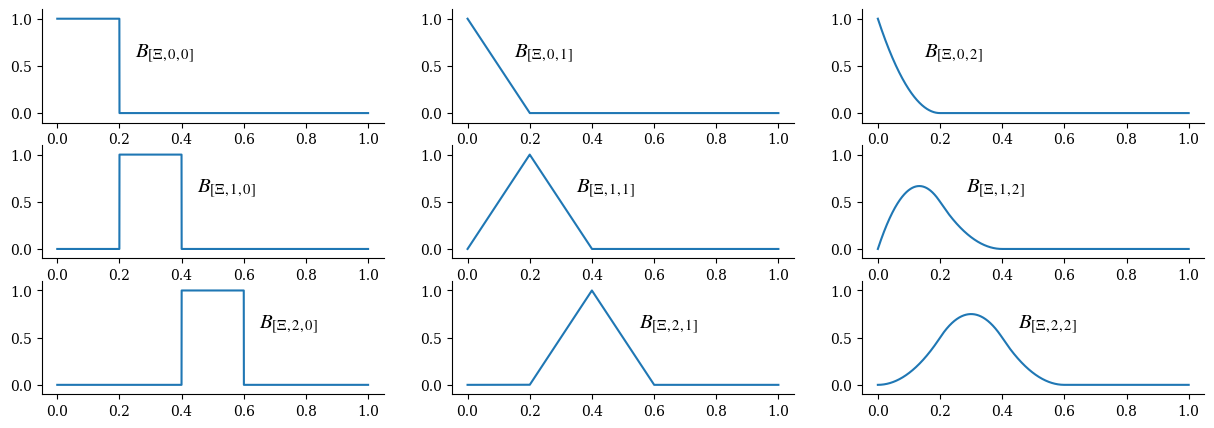

In [8]:
plt.rcParams['mathtext.fontset'] = 'stix'    # STIX is a common serif math font
plt.rcParams['font.family'] = 'serif'        # optional: match text font to math
x = np.linspace(0,1,5001)
kv = bspline.make_knots(0,0,1,5)
M = kv.maximum()
fig, axs = plt.subplots(3,3,figsize=(15,5))
for p in range(3):
    for i in range(3):
        b = bspline.BSplineFunc(kv,np.eye(1,kv.numdofs,i).ravel())
        axs[i,p].plot(x,b(x))
        axs[i,p].set_ylim(-0.1, 1.1) 
        axs[i,p].spines['top'].set_visible(False)
        axs[i,p].spines['right'].set_visible(False)
        axs[i,p].text(M[i]+0.15, 0.6, rf"$B_{{[\Xi,{i},{p}]}}$", fontsize=15)
    kv = bspline.make_knots(p+1,0,1,5)
    M=kv.maximum()
plt.savefig('/home/wolfman/Pictures/recursion.png',bbox_inches='tight',dpi=350);
#plt.tight_layout(pad=0.01) 
#ax.axis('off');

In [6]:
M

array([0.     , 0.45308, 1.10819, 2.     , 3.     , 3.89181, 4.54692, 5.     ])

In [53]:
np.eye(1,kv.numdofs,1).ravel()

array([0., 1., 0., 0., 0.])